# Analisis Kualitas Udara dan Sumber Polutan di Bangkalan

## 1. Business Understanding
**Tujuan Proyek:**
Tujuan utama dari analisis ini adalah untuk mengetahui dan memantau tingkat kualitas udara (khususnya polutan berbahaya seperti CO dan NO2) di wilayah Bangkalan, Jawa Timur. Kita akan melihat tren perubahan polutan selama satu tahun terakhir (September 2025 - 31 Agustus 2026).

**Manfaat Proyek:**
1. **Bagi Pemerintah Daerah:** Menjadi dasar evaluasi dan pengambilan kebijakan terkait regulasi emisi kendaraan, terutama di jalur padat seperti akses Jembatan Suramadu.
2. **Bagi Masyarakat:** Memberikan edukasi dan kesadaran (awareness) terkait waktu-waktu dengan kualitas udara terburuk, sehingga masyarakat bisa membatasi aktivitas luar ruangan atau menggunakan masker.
3. **Bagi Lingkungan:** Mengidentifikasi apakah ada aktivitas industri atau pembakaran lahan yang memicu anomali lonjakan polusi secara tiba-tiba di Bangkalan.

In [1]:
import pandas as pd
import requests
import json

# 1. Tentukan Koordinat Bangkalan (Membatasi wilayah)
latitude = -7.03
longitude = 112.74

# 2. Setup Parameter API (Rentang 1 tahun hingga 31 Agustus 2026)
url = "https://air-quality-api.open-meteo.com/v1/air-quality"
params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": "2025-09-01",
    "end_date": "2026-08-31",
    "hourly": ["carbon_monoxide", "nitrogen_dioxide"]
}

# 3. Crawling Data
response = requests.get(url, params=params)
data = response.json()

# 4. Memasukkan data ke DataFrame
df = pd.DataFrame({
    "tanggal_jam": data['hourly']['time'],
    "CO": data['hourly']['carbon_monoxide'],
    "NO2": data['hourly']['nitrogen_dioxide']
})

# Konversi kolom waktu menjadi tipe datetime
df['tanggal_jam'] = pd.to_datetime(df['tanggal_jam'])

# 5. SIMPAN DATA KE CSV SESUAI SYARAT TUGAS
df.to_csv("data_polutan_bangkalan.csv", index=False)
print("Data berhasil ditarik dan disimpan sebagai 'data_polutan_bangkalan.csv'")

# Tampilkan 5 data teratas
df.head()

Data berhasil ditarik dan disimpan sebagai 'data_polutan_bangkalan.csv'


,tanggal_jam,CO,NO2
0,2025-09-01 00:00:00,760.0,29.7
1,2025-09-01 01:00:00,635.0,23.4
2,2025-09-01 02:00:00,391.0,14.8
3,2025-09-01 03:00:00,207.0,8.1
4,2025-09-01 04:00:00,165.0,5.2


## 2. Data Understanding

Dataset yang digunakan berisi rekaman kualitas udara **per jam** di wilayah Bangkalan, Jawa Timur, selama periode **1 September 2025 sampai 31 Agustus 2026**. Data diperoleh melalui Open-Meteo Air Quality API dan kemudian disimpan dalam format CSV.

### 2.1 Variabel pada Dataset

| Variabel | Keterangan |
|---|---|
| `tanggal_jam` | Waktu pengukuran/perekaman data dalam format tanggal dan jam |
| `CO` | Konsentrasi karbon monoksida dalam μg/m³ |
| `NO2` | Konsentrasi nitrogen dioksida dalam μg/m³ |

Dataset memiliki **8.760 baris data**, yang sesuai dengan data per jam selama satu tahun (365 × 24 jam).

### 2.2 Pengertian Polutan

**1. Karbon Monoksida (CO)**  
Karbon monoksida adalah gas yang tidak berwarna dan tidak berbau. CO terutama terbentuk dari proses pembakaran bahan bakar yang tidak sempurna. Paparan CO dalam konsentrasi tinggi dapat mengganggu kemampuan darah membawa oksigen ke seluruh tubuh. Dalam konteks wilayah perkotaan, salah satu sumber penting CO adalah emisi kendaraan bermotor dan proses pembakaran lainnya.

**2. Nitrogen Dioksida (NO2)**  
Nitrogen dioksida adalah salah satu gas pencemar udara yang umumnya dihasilkan dari proses pembakaran pada suhu tinggi, terutama pembakaran bahan bakar fosil. Sumbernya dapat berasal dari kendaraan bermotor, pembangkit energi, dan aktivitas industri. Paparan NO2 dapat mengiritasi saluran pernapasan dan berkontribusi terhadap pembentukan pencemar udara sekunder.

> **Catatan:** Dataset yang digunakan dalam tugas ini hanya memiliki dua parameter polutan, yaitu **CO dan NO2**. Oleh karena itu, analisis kualitas udara pada tugas ini difokuskan pada kedua parameter tersebut dan tidak dimaksudkan untuk menggambarkan seluruh kondisi kualitas udara.

### 2.3 Interpretasi Awal Sumber Polutan

Dalam konteks Bangkalan, kendaraan bermotor dapat menjadi salah satu sumber emisi CO dan NO2, terutama pada area dengan aktivitas lalu lintas tinggi. Aktivitas pembakaran dan industri juga dapat berkontribusi terhadap emisi. Namun, **data yang tersedia tidak memiliki variabel sumber emisi**, sehingga hubungan antara lonjakan polutan dan aktivitas tertentu tidak dapat disimpulkan secara langsung. Lonjakan pada grafik hanya dapat disebut sebagai **anomali atau perubahan konsentrasi yang perlu dianalisis lebih lanjut**.

### 2.4 Pertanyaan Analisis

Beberapa pertanyaan yang dapat dijawab dari dataset ini:

1. Bagaimana perubahan konsentrasi CO selama satu tahun?
2. Bagaimana perubahan konsentrasi NO2 selama satu tahun?
3. Apakah terdapat pola atau tren tertentu berdasarkan waktu?
4. Pada periode kapan terjadi konsentrasi CO atau NO2 yang relatif tinggi?
5. Apakah terdapat data kosong atau nilai negatif yang perlu dibersihkan?


In [2]:
# Mengecek ukuran dataset
print("Jumlah baris dan kolom:", df.shape)

# Mengecek tipe data
print("\nTipe data:")
print(df.dtypes)

# Mengecek data kosong
print("\nJumlah data kosong:")
print(df.isnull().sum())

# Mengecek nilai negatif pada polutan
data_aneh = df[(df['CO'] < 0) | (df['NO2'] < 0)]
print("\nJumlah data anomali (negatif):", len(data_aneh))

# Menampilkan statistik deskriptif
print("\nStatistik deskriptif:")
display(df[['CO', 'NO2']].describe())


Jumlah baris dan kolom: (8760, 3)

Tipe data:
tanggal_jam    datetime64[ns]
CO                    float64
NO2                   float64
dtype: object

Jumlah data kosong:
tanggal_jam    0
CO             0
NO2            0
dtype: int64

Jumlah data anomali (negatif): 0

Statistik deskriptif:


,CO,NO2
count,8760.000000,8760.000000
mean,341.515639,33.734989
std,190.568504,23.514247
min,57.000000,2.700000
25%,225.000000,16.000000
50%,290.500000,28.300000
75%,396.000000,46.000000
max,2153.000000,195.500000


## 3. Data Preparation untuk Time Series

Karena data dicatat setiap jam, visualisasi selama 8.760 titik sekaligus dapat terlihat terlalu padat. Untuk melihat **tren jangka panjang**, data diringkas menjadi rata-rata harian.

Perhitungan rata-rata harian tidak menghapus data asli. Data asli tetap digunakan sebagai sumber, sedangkan `df_harian` hanya merupakan hasil agregasi untuk keperluan visualisasi.

In [3]:
# Pastikan kolom waktu bertipe datetime
df['tanggal_jam'] = pd.to_datetime(df['tanggal_jam'])

# Urutkan berdasarkan waktu
df = df.sort_values('tanggal_jam')

# Rata-rata harian untuk visualisasi time series
df_harian = (
    df.set_index('tanggal_jam')[['CO', 'NO2']]
      .resample('D')
      .mean()
)

print("Jumlah titik time series harian:", len(df_harian))
display(df_harian.head())


Jumlah titik time series harian: 365


,CO,NO2
tanggal_jam,,
2025-09-01,232.166667,12.308333
2025-09-02,181.791667,12.716667
2025-09-03,228.041667,18.191667
2025-09-04,268.458333,24.716667
2025-09-05,339.500000,26.400000


## 4. Visualisasi Time Series CO

Grafik berikut menunjukkan perubahan rata-rata konsentrasi **CO (Karbon Monoksida)** dari hari ke hari selama periode pengamatan. Sumbu X menunjukkan waktu, sedangkan sumbu Y menunjukkan konsentrasi CO dalam μg/m³.

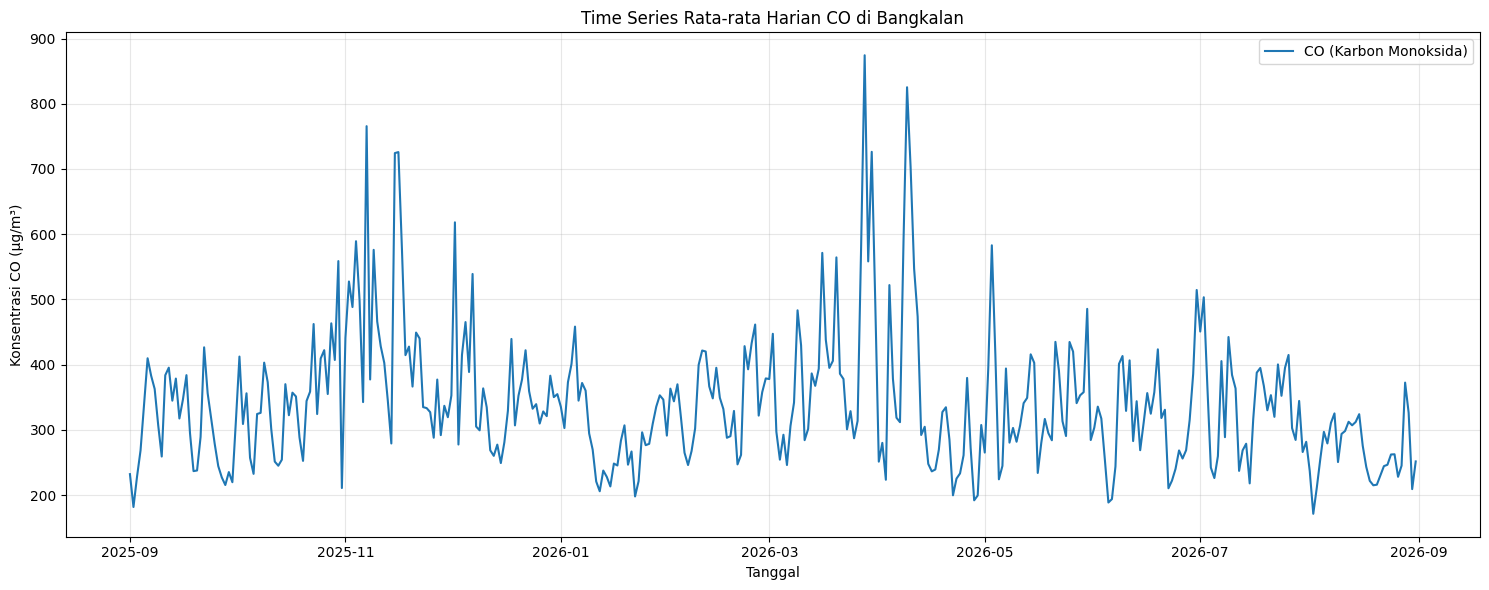

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.plot(
    df_harian.index,
    df_harian['CO'],
    label='CO (Karbon Monoksida)'
)

plt.title('Time Series Rata-rata Harian CO di Bangkalan')
plt.xlabel('Tanggal')
plt.ylabel('Konsentrasi CO (μg/m³)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Visualisasi Time Series NO2

Grafik berikut menunjukkan perubahan rata-rata konsentrasi **NO2 (Nitrogen Dioksida)** dari hari ke hari selama periode pengamatan.

CO dan NO2 divisualisasikan secara terpisah karena skala nilainya berbeda. Pemisahan ini membuat perubahan masing-masing polutan lebih mudah dibaca.

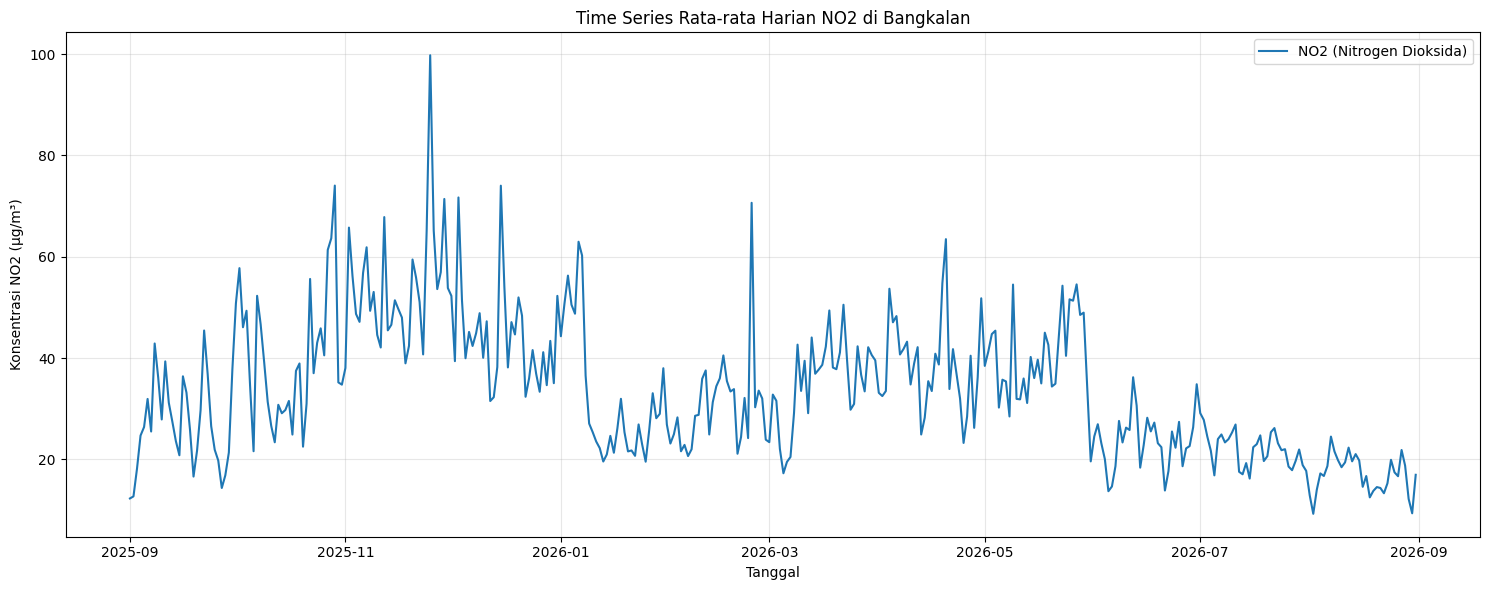

In [5]:
plt.figure(figsize=(15, 6))
plt.plot(
    df_harian.index,
    df_harian['NO2'],
    label='NO2 (Nitrogen Dioksida)'
)

plt.title('Time Series Rata-rata Harian NO2 di Bangkalan')
plt.xlabel('Tanggal')
plt.ylabel('Konsentrasi NO2 (μg/m³)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Perbandingan Pola CO dan NO2

Karena CO dan NO2 memiliki skala konsentrasi yang berbeda, perbandingan langsung pada satu sumbu Y kurang ideal. Untuk membandingkan **bentuk pola/pergerakannya**, kedua variabel dapat dinormalisasi menggunakan Min-Max Scaling.

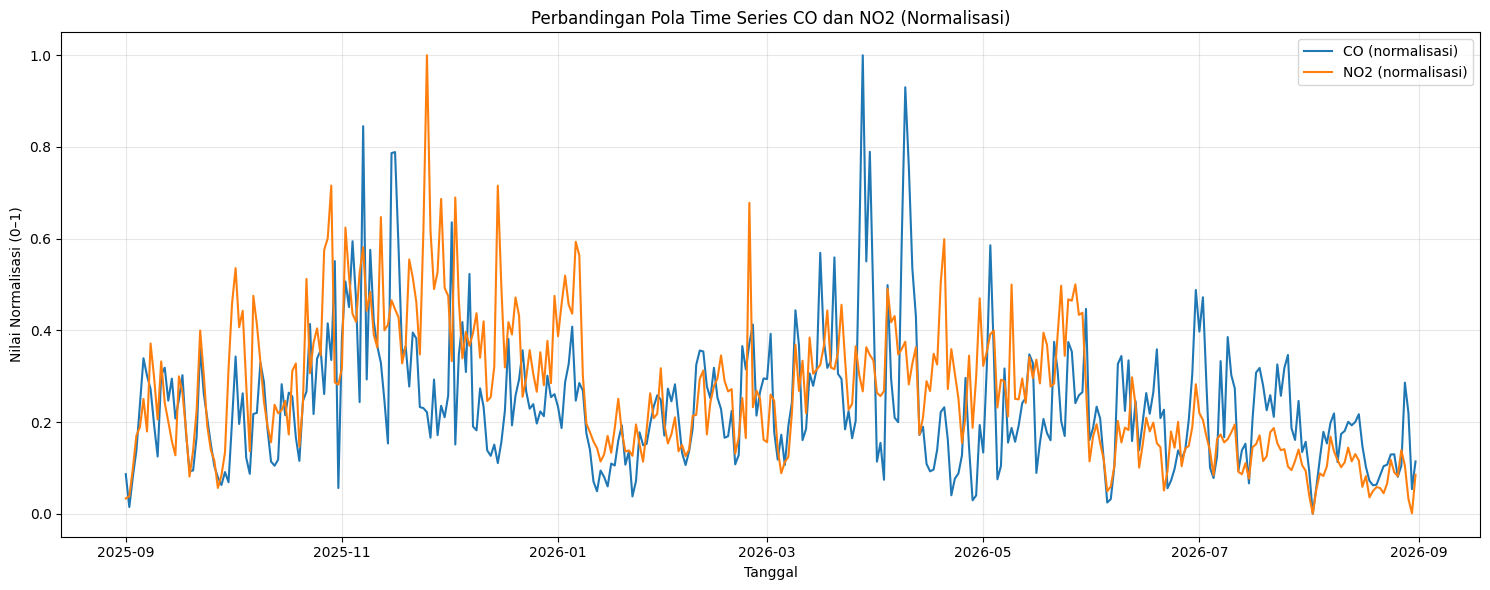

In [6]:
# Min-Max normalization untuk membandingkan pola
df_norm = df_harian.copy()

for col in ['CO', 'NO2']:
    min_val = df_norm[col].min()
    max_val = df_norm[col].max()
    df_norm[col] = (df_norm[col] - min_val) / (max_val - min_val)

plt.figure(figsize=(15, 6))
plt.plot(df_norm.index, df_norm['CO'], label='CO (normalisasi)')
plt.plot(df_norm.index, df_norm['NO2'], label='NO2 (normalisasi)')

plt.title('Perbandingan Pola Time Series CO dan NO2 (Normalisasi)')
plt.xlabel('Tanggal')
plt.ylabel('Nilai Normalisasi (0–1)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 7. Implementasi Analisis di KNIME

Analisis yang sama juga dapat dilakukan menggunakan **KNIME Analytics Platform** dengan mengambil data langsung dari PostgreSQL yang sudah tersimpan di Aiven.

## 7.1 Alur Node KNIME

Workflow dasar:

```text
PostgreSQL Connector
        ↓
DB Table Selector
        ↓
DB Reader
        ↓
Column Filter (opsional)
        ↓
String to Date&Time / Date&Time Configuration
        ↓
Time Series Configuration
        ↓
Line Plot / Time Series Plot
```

Pada workflow yang sudah dibuat, tiga node pertama sudah benar:

**PostgreSQL Connector → DB Table Selector → DB Reader**

Node tersebut digunakan untuk mengambil tabel `data_polutan_bangkalan` dari PostgreSQL.

## 7.2 Langkah-Langkah di KNIME

### Langkah 1 — PostgreSQL Connector

1. Buka KNIME dan buat workflow baru.
2. Cari node **PostgreSQL Connector**.
3. Tarik node ke workflow.
4. Klik dua kali node tersebut.
5. Isi informasi koneksi dari Aiven:
   - Host
   - Port
   - Database
   - Username
   - Password
6. Gunakan pengaturan SSL sesuai konfigurasi koneksi Aiven.
7. Klik **Test Connection**.
8. Jika berhasil, klik **OK**.

> Password Aiven bersifat rahasia dan jangan dimasukkan ke laporan atau screenshot tugas.

### Langkah 2 — DB Table Selector

1. Cari node **DB Table Selector**.
2. Hubungkan output dari `PostgreSQL Connector` ke `DB Table Selector`.
3. Buka konfigurasi node.
4. Pilih schema/database yang digunakan.
5. Pilih tabel:
   `data_polutan_bangkalan`
6. Klik **OK**.

### Langkah 3 — DB Reader

1. Cari node **DB Reader**.
2. Hubungkan `DB Table Selector` → `DB Reader`.
3. Execute node.
4. Buka hasil tabel untuk memastikan data sudah terbaca.

Data yang diharapkan memiliki kolom:

```text
id
tanggal_jam
co
no2
```

dan jumlah data sekitar **8.760 baris**.

### Langkah 4 — Mengecek Statistik

Node **Statistics** dapat digunakan untuk melihat ringkasan statistik data.

Hubungkan:

```text
DB Reader → Statistics
```

Kemudian execute.

Gunakan node ini untuk melihat nilai seperti:
- minimum
- maksimum
- mean/rata-rata
- standar deviasi
- jumlah data

### Langkah 5 — Mengubah Kolom Waktu

Kolom `tanggal_jam` harus dikenali sebagai tipe **Date&Time** agar dapat digunakan untuk time series.

Jika setelah `DB Reader` kolom waktu belum dikenali sebagai Date&Time, gunakan node yang sesuai untuk konversi tipe tanggal/waktu, misalnya:

**String to Date&Time**

Konfigurasi format waktu:

```text
yyyy-MM-dd HH:mm:ss
```

Contoh:

```text
2025-09-01 00:00:00
```

### Langkah 6 — Membuat Time Series

Untuk visualisasi time series, gunakan node visualisasi time series/line plot yang tersedia pada versi KNIME yang digunakan.

Atur:
- **X-axis** → `tanggal_jam`
- **Y-axis** → `co`

Kemudian buat visualisasi kedua:
- **X-axis** → `tanggal_jam`
- **Y-axis** → `no2`

Hasilnya adalah dua grafik yang menunjukkan perubahan CO dan NO2 terhadap waktu.

### Langkah 7 — Jika Grafik Terlalu Padat

Data memiliki 8.760 titik per jam. Jika grafik terlalu padat, lakukan agregasi terlebih dahulu menjadi rata-rata harian.

Konsepnya:

```text
tanggal_jam
     ↓
ambil tanggal
     ↓
Group By / agregasi harian
     ↓
AVG(co)
AVG(no2)
     ↓
Line Plot
```

Dengan demikian, satu tahun data menjadi sekitar 365 titik harian sehingga tren lebih mudah dibaca.

## 7.3 Workflow KNIME yang Direkomendasikan

Untuk tugas ini, workflow dapat dikembangkan menjadi:

```text
PostgreSQL Connector
        ↓
DB Table Selector
        ↓
DB Reader
        ↓
Data Validation
        ↓
Column Filter
        ↓
Date&Time Processing
        ↓
Aggregation / Group By
        ↓
     ┌──┴───┐
     ↓      ↓
   CO      NO2
     ↓      ↓
  Line    Line
  Plot    Plot
```

Sedangkan node **Statistics** dapat diletakkan setelah `DB Reader` untuk mendapatkan statistik deskriptif.

## 7.4 Output yang Diharapkan

Setelah workflow selesai, hasil analisis minimal terdiri dari:

1. Data berhasil dibaca dari PostgreSQL Aiven.
2. Statistik deskriptif CO dan NO2.
3. Grafik **time series CO**.
4. Grafik **time series NO2**.
5. Jika diperlukan, grafik perbandingan pola CO dan NO2 setelah normalisasi.
6. Kesimpulan mengenai pola perubahan konsentrasi polutan selama periode pengamatan.

> **Catatan interpretasi:** grafik time series menunjukkan pola perubahan konsentrasi dari waktu ke waktu. Grafik tersebut belum cukup untuk membuktikan penyebab suatu lonjakan polusi. Untuk menentukan sumber penyebab, diperlukan variabel tambahan seperti volume lalu lintas, cuaca, aktivitas industri, atau data emisi.


# 8. Kesimpulan Sementara

Berdasarkan tahap Data Understanding dan visualisasi time series, dataset ini dapat digunakan untuk mengamati perubahan konsentrasi **CO dan NO2** di Bangkalan selama periode September 2025–Agustus 2026.

Analisis time series membantu mengidentifikasi pola perubahan dan periode dengan konsentrasi yang relatif tinggi atau rendah. Tahap berikutnya dapat dikembangkan menjadi analisis yang lebih mendalam, seperti analisis pola berdasarkan **jam, hari, bulan**, deteksi anomali, korelasi antara CO dan NO2, atau pemodelan prediksi.

**Kesimpulan akhir sebaiknya ditulis setelah grafik dijalankan dan hasil pengamatan terhadap pola data benar-benar tersedia.**
